# Two-Stage ML Pipeline for Thermal Comfort

This notebook solves the "subjectivity paradox" by breaking the problem into two distinct stages:
1. **Stage 1 (Physics to Perception):** Train 4 classifiers to predict how the room *feels* (Cool/Optimal/Warm, Quiet/Noisy) based directly on the raw sensor data.
2. **Stage 2 (Perception to Comfort):** Train a final model that takes those predicted feelings and outputs the final 1-5 overall Comfort score.

To prevent data leakage, we use `cross_val_predict` to generate out-of-fold predictions for our training set, simulating a real-world scenario where Stage 1 predictions aren't "perfect".


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [8]:
# 1. Load Data
data_path = '../../data/processed/instant_mock.csv'
df = pd.read_csv(data_path)

# Map target and raw features
sensor_cols = ['temperature', 'humidity', 'noise', 'co2', 'light']
perception_cols = ['temperatureValue', 'humidityValue', 'noiseValue', 'airQualityValue']
target_col = 'comfortValue'

# Clean data
df = df[sensor_cols + perception_cols + [target_col]].copy()
df = df.dropna()

for col in perception_cols + [target_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

print(f"Total rows for Two-Stage Pipeline: {len(df):,}")


Total rows for Two-Stage Pipeline: 1,812


In [9]:
# 2. Train/Test Split
X = df[sensor_cols]
y_perceptions = df[perception_cols]
y_comfort = df[target_col]

X_train, X_test, y_perc_train, y_perc_test, y_comf_train, y_comf_test = train_test_split(
    X, y_perceptions, y_comfort, test_size=0.20, random_state=42, shuffle=True
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")


Train size: 1449
Test size: 363


In [10]:
# 3. Stage 1: Train Perception Classifiers
from sklearn.preprocessing import OneHotEncoder

stage1_models = {}
X_train_stage2_raw = pd.DataFrame(index=X_train.index)
X_test_stage2_raw = pd.DataFrame(index=X_test.index)

print("--- Training Stage 1 Perception Models ---")
for col in perception_cols:
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
    oof_preds = cross_val_predict(clf, X_train, y_perc_train[col], cv=5)
    X_train_stage2_raw[f"pred_{col}"] = oof_preds
    
    clf.fit(X_train, y_perc_train[col])
    stage1_models[col] = clf
    X_test_stage2_raw[f"pred_{col}"] = clf.predict(X_test)

# Apply One-Hot Encoding to the predicted perception labels
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_train = encoder.fit_transform(X_train_stage2_raw)
encoded_test = encoder.transform(X_test_stage2_raw)

encoded_cols = encoder.get_feature_names_out(X_train_stage2_raw.columns)
X_train_stage2_ohe = pd.DataFrame(encoded_train, columns=encoded_cols, index=X_train.index)
X_test_stage2_ohe = pd.DataFrame(encoded_test, columns=encoded_cols, index=X_test.index)

# Combine One-Hot Encoded perceptions with original sensor data
X_train_final = pd.concat([X_train_stage2_ohe, X_train], axis=1)
X_test_final = pd.concat([X_test_stage2_ohe, X_test], axis=1)

print("\nFinal Feature Set for Stage 2 (First 5 rows):")
display(X_train_final.head())


--- Training Stage 1 Perception Models ---

Final Feature Set for Stage 2 (First 5 rows):


,pred_temperatureValue_-2,pred_temperatureValue_-1,pred_temperatureValue_0,pred_temperatureValue_1,pred_temperatureValue_2,pred_humidityValue_-2,pred_humidityValue_-1,pred_humidityValue_0,pred_humidityValue_1,pred_humidityValue_2,...,pred_noiseValue_1,pred_noiseValue_2,pred_airQualityValue_0,pred_airQualityValue_1,pred_airQualityValue_2,temperature,humidity,noise,co2,light
1460,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,22.5,2209.0,8.124038,0.001027,5.390830
1083,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,22.7,3721.0,7.745967,0.001441,5.680899
1746,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,21.7,1764.0,7.615773,0.001471,0.000000
906,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,24.3,1444.0,7.000000,0.002123,5.590925
1047,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,21.3,3969.0,7.681146,0.001513,5.482805


In [11]:
# 4. Stage 2: Train Overall Comfort Model (Simple Regressor & Classifier)

# ---- REGRESSOR ----
regressor = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
regressor.fit(X_train_final, y_comf_train)

test_preds_reg = regressor.predict(X_test_final)
train_preds_reg = regressor.predict(X_train_final)
mae_reg = mean_absolute_error(y_comf_test, test_preds_reg)

print("--- Stage 2 Regressor Results ---")
print(f"Test MAE: {mae_reg:.3f}")

# ---- CLASSIFIER ----
classifier = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
classifier.fit(X_train_final, y_comf_train)

test_preds_clf = classifier.predict(X_test_final)
train_preds_clf = classifier.predict(X_train_final)
acc_clf = accuracy_score(y_comf_test, test_preds_clf)
mae_clf = mean_absolute_error(y_comf_test, test_preds_clf)

print("\n--- Stage 2 Classifier Results ---")
print(f"Test Accuracy: {acc_clf:.3f}")
print(f"Test MAE: {mae_clf:.3f}")


--- Stage 2 Regressor Results ---
Test MAE: 0.731

--- Stage 2 Classifier Results ---
Test Accuracy: 0.364
Test MAE: 0.851


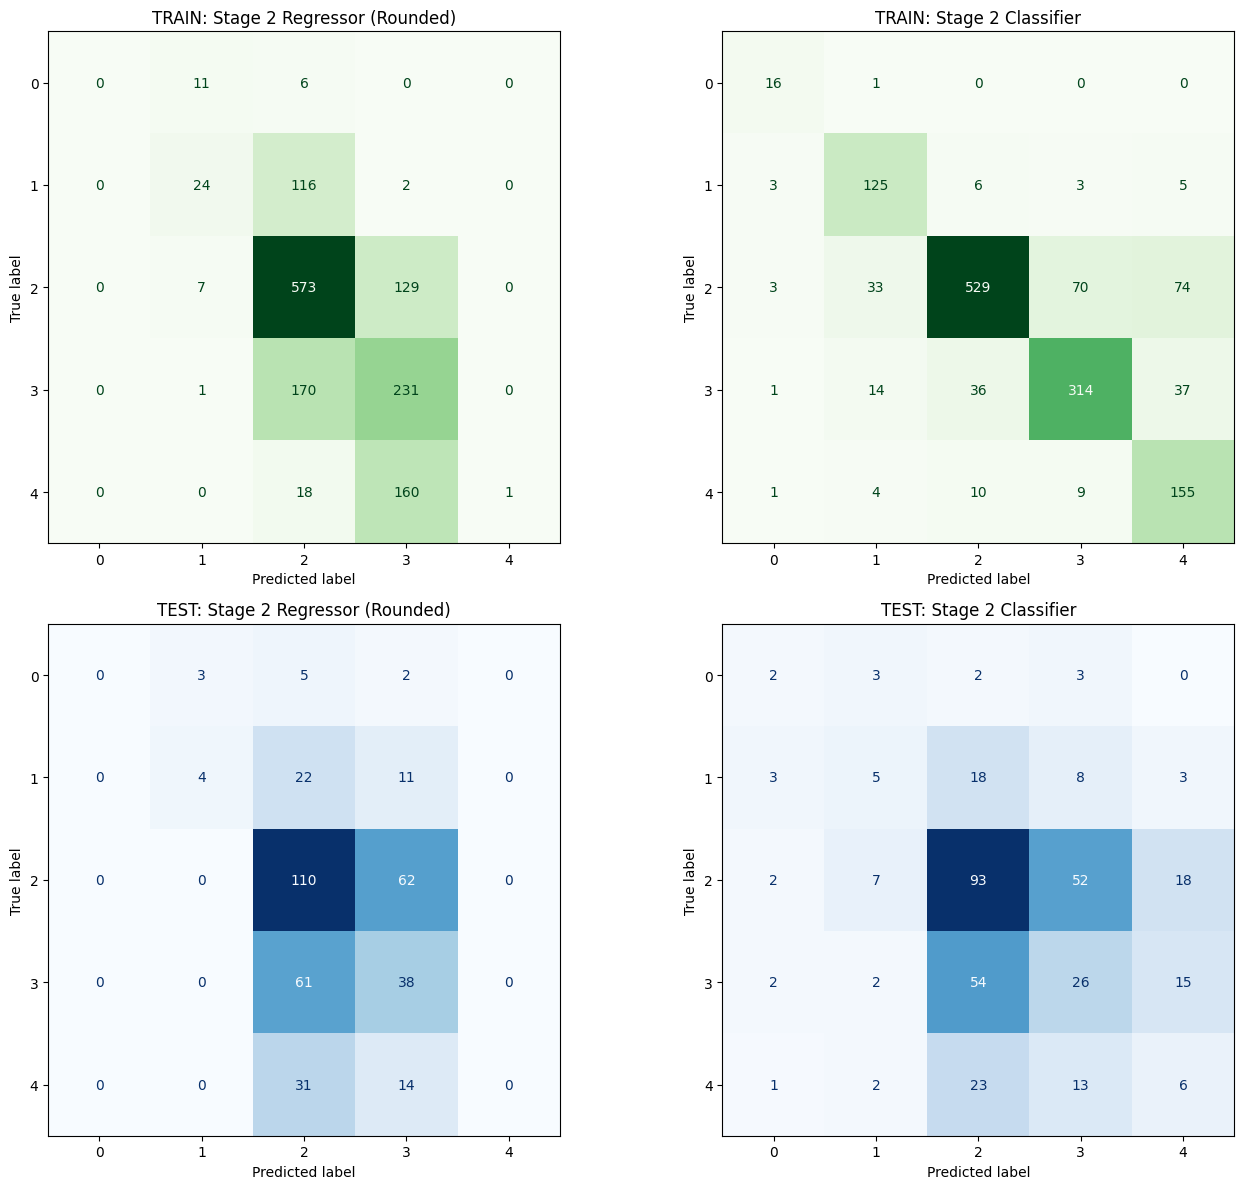

In [12]:
# 5. Confusion Matrices (Train vs Test)

# For Regressor, round predictions to nearest integer
test_preds_reg_rounded = np.clip(np.round(test_preds_reg), y_comf_train.min(), y_comf_train.max())
train_preds_reg_rounded = np.clip(np.round(train_preds_reg), y_comf_train.min(), y_comf_train.max())

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- TRAINING DATA (Top Row) ---
# Train: Regressor
cm_reg_train = confusion_matrix(y_comf_train, train_preds_reg_rounded)
disp_reg_train = ConfusionMatrixDisplay(confusion_matrix=cm_reg_train)
disp_reg_train.plot(ax=axes[0, 0], cmap='Greens', colorbar=False)
axes[0, 0].set_title('TRAIN: Stage 2 Regressor (Rounded)')

# Train: Classifier
cm_clf_train = confusion_matrix(y_comf_train, train_preds_clf)
disp_clf_train = ConfusionMatrixDisplay(confusion_matrix=cm_clf_train)
disp_clf_train.plot(ax=axes[0, 1], cmap='Greens', colorbar=False)
axes[0, 1].set_title('TRAIN: Stage 2 Classifier')

# --- TESTING DATA (Bottom Row) ---
# Test: Regressor
cm_reg_test = confusion_matrix(y_comf_test, test_preds_reg_rounded)
disp_reg_test = ConfusionMatrixDisplay(confusion_matrix=cm_reg_test)
disp_reg_test.plot(ax=axes[1, 0], cmap='Blues', colorbar=False)
axes[1, 0].set_title('TEST: Stage 2 Regressor (Rounded)')

# Test: Classifier
cm_clf_test = confusion_matrix(y_comf_test, test_preds_clf)
disp_clf_test = ConfusionMatrixDisplay(confusion_matrix=cm_clf_test)
disp_clf_test.plot(ax=axes[1, 1], cmap='Blues', colorbar=False)
axes[1, 1].set_title('TEST: Stage 2 Classifier')

plt.tight_layout()
plt.show()


## Final Conclusion: The Subjectivity Paradox & Overfitting

As seen in the Train vs Test confusion matrices above, the models suffer from severe **overfitting** when attempting to predict extreme comfort values (1 and 5). 

* **The Classifier** memorizes specific rows in the training data (creating a strong diagonal in the Train matrix), but completely fails to generalize on new test data, randomly scattering its predictions.
* **The Regressor** plays it safe mathematically by predicting the mean (~2.5) for almost every row, failing to identify extreme comfort altogether.

**Why does this happen?** 
This is the ultimate proof of the "Subjectivity Paradox". Because we do not split the data into **user profiles** (e.g., `user_type`, `respondentId`), the physical sensors (`temperature`, `humidity`) lack the necessary context to mathematically separate someone who "runs hot" from someone who "runs cold" in the exact same room conditions. 

Without individual user profiles, the physical sensors alone do not contain enough generalizable signal to predict extreme subjective discomfort across a diverse population.
